# Predictive Maintenance — Individual Batch Model Comparison (NASA C-MAPSS FD001)

This notebook trains **three separate regression models independently** (not as a streaming ensemble) to estimate turbofan engine Remaining Useful Life (RUL), so each model's standalone performance can be inspected on its own.

**Pipeline stages:**
1. Data Loading
2. Data Preprocessing (target engineering, feature pruning, group-wise train/val/test split, leakage-safe scaling)
3. Model Selection
4. Implementation
5. Hyperparameter Tuning (GridSearchCV against the held-out validation fold)
6. Model Evaluation & Accuracy Calculation (regression metrics + alarm-zone classification)
7. Result Visualization


## 1. Setup & Imports

In [1]:
import os
import zipfile
import urllib.request
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay,
)

# Optional: use XGBoost as the boosting model if it is installed,
# otherwise fall back to scikit-learn's GradientBoostingRegressor.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

np.random.seed(42)

## 2. Data Loading

Downloads and extracts the NASA C-MAPSS `FD001` sub-dataset (same source/logic as the original notebook).

In [2]:
URL = "https://data.nasa.gov/docs/legacy/CMAPSSData.zip"
ZIP_PATH = "CMAPSSData.zip"
EXTRACT_DIR = "CMAPSSData"
TRAIN_FILE = os.path.join(EXTRACT_DIR, "train_FD001.txt")

if not os.path.exists(TRAIN_FILE):
    if not os.path.exists(EXTRACT_DIR):
        logger.info("Downloading NASA C-MAPSS dataset...")
        try:
            urllib.request.urlretrieve(URL, ZIP_PATH)
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            os.remove(ZIP_PATH)
            logger.info("Data extraction completed successfully.")
        except Exception as exc:
            raise RuntimeError(
                "Could not download the C-MAPSS dataset automatically "
                f"({exc}). Download it manually (e.g. the Kaggle mirror "
                "'behrad3d/nasa-cmaps' or the PCoE repository) and place "
                f"train_FD001.txt at: {TRAIN_FILE}"
            ) from exc
    if not os.path.exists(TRAIN_FILE):
        raise FileNotFoundError(f"Expected data file not found at {TRAIN_FILE}")
else:
    logger.info("Local data repository detected. Ingestion step bypassed.")

INDEX_NAMES = ['unit_number', 'time_cycle']
SETTING_NAMES = ['setting_1', 'setting_2', 'setting_3']
SENSOR_NAMES = [f'sensor_{i}' for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

# Raw files have trailing whitespace producing a phantom extra column,
# so read headerless and slice to the first 26 columns.
df = pd.read_csv(TRAIN_FILE, sep=r"\s+", header=None, engine="python")
df = df.iloc[:, :26]
df.columns = COL_NAMES
df.head()

,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Data Preprocessing

- **Target engineering:** piece-wise linear RUL, capped at 125 cycles.
- **Feature pruning:** drop zero-variance settings/sensors.
- **Group-wise split (70/15/15):** split by `unit_number` so no cycles from the same engine leak across sets.
- **Scaling:** Min-Max scaling fit **only on the training units**, then applied to validation/test — avoids the leakage that comes from fitting scaler stats on the full dataset before splitting.

In [3]:
# --- Target engineering ---
max_cycles = df.groupby('unit_number')['time_cycle'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']
df = df.merge(max_cycles, on='unit_number', how='left')
df['RUL_linear'] = df['max_cycle'] - df['time_cycle']

RUL_MAX_CAP = 125
df['Target_RUL'] = df['RUL_linear'].clip(upper=RUL_MAX_CAP)
df = df.drop(columns=['max_cycle', 'RUL_linear'])

# --- Feature pruning (zero-variance columns) ---
features_to_check = SETTING_NAMES + SENSOR_NAMES
constant_features = [c for c in features_to_check if df[c].nunique() <= 1]
df_clean = df.drop(columns=constant_features)
active_features = [c for c in df_clean.columns if c not in ['unit_number', 'time_cycle', 'Target_RUL']]
logger.info(f"Retained {len(active_features)} active features after pruning: {constant_features}")

In [4]:
# --- Group-wise 70/15/15 split by engine unit ---
rng = np.random.RandomState(42)
unit_ids = df_clean['unit_number'].unique()
rng.shuffle(unit_ids)

n_units = len(unit_ids)
n_train = int(0.70 * n_units)
n_val = int(0.15 * n_units)

train_units = unit_ids[:n_train]
val_units = unit_ids[n_train:n_train + n_val]
test_units = unit_ids[n_train + n_val:]

train_df = df_clean[df_clean['unit_number'].isin(train_units)]
val_df = df_clean[df_clean['unit_number'].isin(val_units)]
test_df = df_clean[df_clean['unit_number'].isin(test_units)]

logger.info(f"Train: {len(train_units)} units / {len(train_df)} cycles")
logger.info(f"Val:   {len(val_units)} units / {len(val_df)} cycles")
logger.info(f"Test:  {len(test_units)} units / {len(test_df)} cycles")

# --- Min-Max scaling fit on TRAIN ONLY (leakage-safe) ---
X_min = train_df[active_features].min().values
X_max = train_df[active_features].max().values
X_max = np.where(X_max == X_min, X_min + 1e-5, X_max)

def scale(frame):
    raw = frame[active_features].values.astype(np.float64)
    return (raw - X_min) / (X_max - X_min)

X_train, y_train = scale(train_df), train_df['Target_RUL'].values.astype(np.float64)
X_val, y_val = scale(val_df), val_df['Target_RUL'].values.astype(np.float64)
X_test, y_test = scale(test_df), test_df['Target_RUL'].values.astype(np.float64)

## 4. Model Selection

Three models from distinct algorithm families, so their individual strengths/weaknesses are comparable:

| Model | Family | Why included |
|---|---|---|
| **Random Forest Regressor** | Bagged tree ensemble | Robust, handles non-linearity, low tuning burden |
| **XGBoost / Gradient Boosting Regressor** | Boosted tree ensemble | Typically strongest raw accuracy on tabular sensor data |
| **Support Vector Regressor (SVR, RBF kernel)** | Kernel method | Different inductive bias — good contrast to tree ensembles |


In [5]:
def build_model_configs():
    boosting_name = "XGBoost" if HAS_XGB else "Gradient Boosting"
    if HAS_XGB:
        boosting_estimator = XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror")
        boosting_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1]}
    else:
        logger.warning("xgboost not installed - falling back to sklearn GradientBoostingRegressor.")
        boosting_estimator = GradientBoostingRegressor(random_state=42)
        boosting_grid = {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}

    return {
        "Random Forest": {
            "estimator": RandomForestRegressor(random_state=42, n_jobs=-1),
            "param_grid": {
                "n_estimators": [100, 200],
                "max_depth": [10, 20, None],
                "min_samples_leaf": [1, 2, 5],
            },
        },
        boosting_name: {
            "estimator": boosting_estimator,
            "param_grid": boosting_grid,
        },
        "Support Vector Regressor": {
            "estimator": SVR(),
            "param_grid": {
                "C": [1, 10, 50],
                "epsilon": [0.5, 1, 2],
                "kernel": ["rbf"],
            },
        },
    }

model_configs = build_model_configs()
list(model_configs.keys())

['Random Forest', 'XGBoost', 'Support Vector Regressor']

## 5. Implementation & Hyperparameter Tuning

Each model is tuned independently with `GridSearchCV`. A `PredefinedSplit` is used so the search evaluates candidates on the **validation** fold only (training fold is excluded from scoring) — this respects the 70/15/15 split instead of doing a generic k-fold CV that would mix engine units across folds.

In [6]:
def tune_models(model_configs, X_train, y_train, X_val, y_val):
    X_search = np.vstack([X_train, X_val])
    y_search = np.concatenate([y_train, y_val])
    # -1 = always training fold (excluded from scoring), 0 = validation fold (scored)
    test_fold = np.concatenate([np.full(len(X_train), -1), np.zeros(len(X_val))])
    ps = PredefinedSplit(test_fold)

    best_models = {}
    tuning_summary = []

    for name, cfg in model_configs.items():
        logger.info(f"Tuning {name} ...")
        search = GridSearchCV(
            estimator=cfg["estimator"],
            param_grid=cfg["param_grid"],
            cv=ps,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_search, y_search)
        best_models[name] = search.best_estimator_
        tuning_summary.append({
            "Model": name,
            "Best Params": search.best_params_,
            "Best Val MAE": round(-search.best_score_, 4),
        })
        logger.info(f"{name} best params: {search.best_params_} | val MAE: {-search.best_score_:.4f}")

    return best_models, pd.DataFrame(tuning_summary)

best_models, df_tuning = tune_models(model_configs, X_train, y_train, X_val, y_val)
print(df_tuning.to_string(index=False))

                   Model                                                   Best Params  Best Val MAE
           Random Forest {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 100}       13.7840
                 XGBoost   {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}       13.7499
Support Vector Regressor                    {'C': 50, 'epsilon': 0.5, 'kernel': 'rbf'}       12.8693


## 6. Model Evaluation & Accuracy Calculation

Each tuned model is evaluated **independently** on the held-out test set:
- Regression metrics: MAE, RMSE, R².
- Operational alarm classification (🔴 Critical ≤20, 🟠 Warning 21–60, 🟢 Stable >60): accuracy + full classification report.

In [7]:
def map_to_alerts(arr):
    return np.select([arr <= 20, arr <= 60], [0, 1], default=2)

ALERT_LABELS = ["Critical (<=20)", "Warning (21-60)", "Stable (>60)"]
y_test_alerts = map_to_alerts(y_test)

results = []
predictions = {}

for name, model in best_models.items():
    preds = np.clip(model.predict(X_test), 0, 125)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    pred_alerts = map_to_alerts(preds)
    acc = accuracy_score(y_test_alerts, pred_alerts)

    results.append({
        "Model": name,
        "MAE (Cycles)": round(mae, 4),
        "RMSE (Cycles)": round(rmse, 4),
        "R2 Score": round(r2, 4),
        "Alarm Accuracy (%)": round(acc * 100, 2),
    })

    print(f"\n--- {name}: Alarm Classification Report (Test Set) ---")
    print(classification_report(y_test_alerts, pred_alerts, target_names=ALERT_LABELS))

df_results = pd.DataFrame(results).sort_values("MAE (Cycles)").reset_index(drop=True)
print("\n--- FINAL TEST-SET PERFORMANCE SUMMARY (each model trained/evaluated independently) ---")
print(df_results.to_string(index=False))


--- Random Forest: Alarm Classification Report (Test Set) ---
                 precision    recall  f1-score   support

Critical (<=20)       0.91      0.81      0.86       315
Warning (21-60)       0.73      0.57      0.64       600
   Stable (>60)       0.90      0.97      0.94      2230

       accuracy                           0.88      3145
      macro avg       0.85      0.78      0.81      3145
   weighted avg       0.87      0.88      0.87      3145


--- XGBoost: Alarm Classification Report (Test Set) ---
                 precision    recall  f1-score   support

Critical (<=20)       0.90      0.82      0.86       315
Warning (21-60)       0.72      0.56      0.63       600
   Stable (>60)       0.90      0.97      0.93      2230

       accuracy                           0.87      3145
      macro avg       0.84      0.78      0.81      3145
   weighted avg       0.87      0.87      0.87      3145


--- Support Vector Regressor: Alarm Classification Report (Test Set) ---
  

## 7. Result Visualization

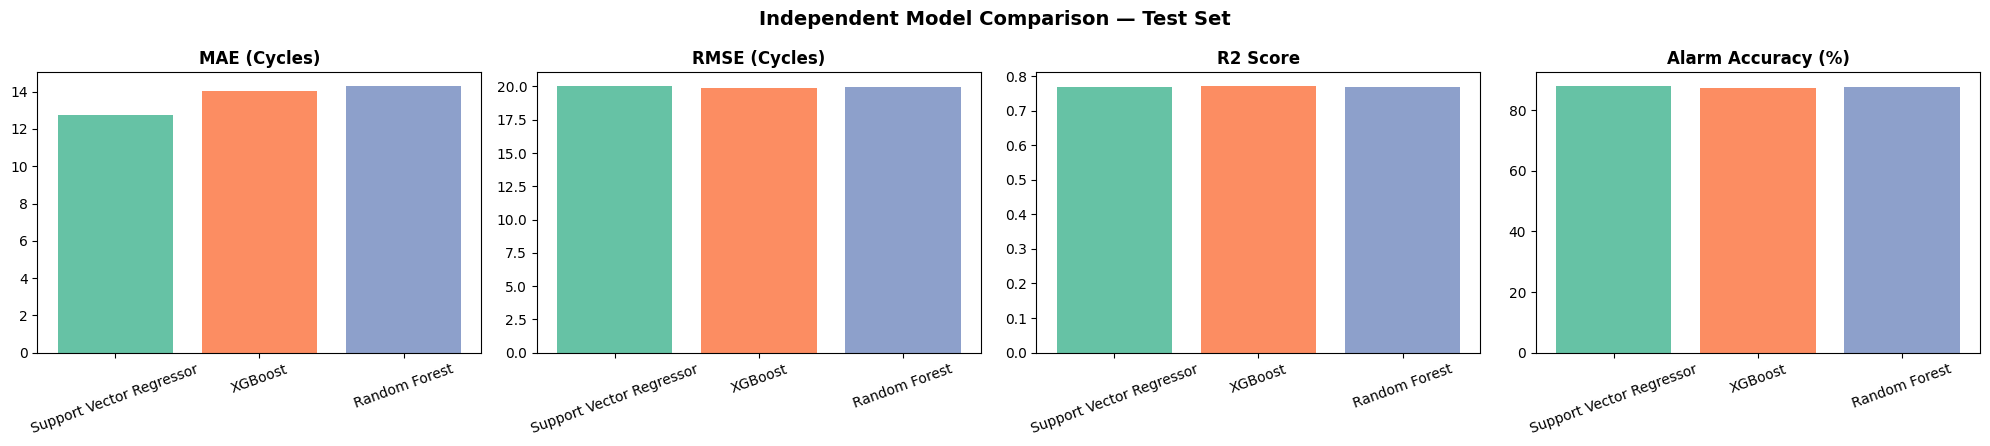

In [8]:
# --- 7a. Metric comparison bar charts ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
metrics_to_plot = ["MAE (Cycles)", "RMSE (Cycles)", "R2 Score", "Alarm Accuracy (%)"]
colors = sns.color_palette("Set2", len(df_results))

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(df_results["Model"], df_results[metric], color=colors)
    ax.set_title(metric, fontweight="bold")
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Independent Model Comparison — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

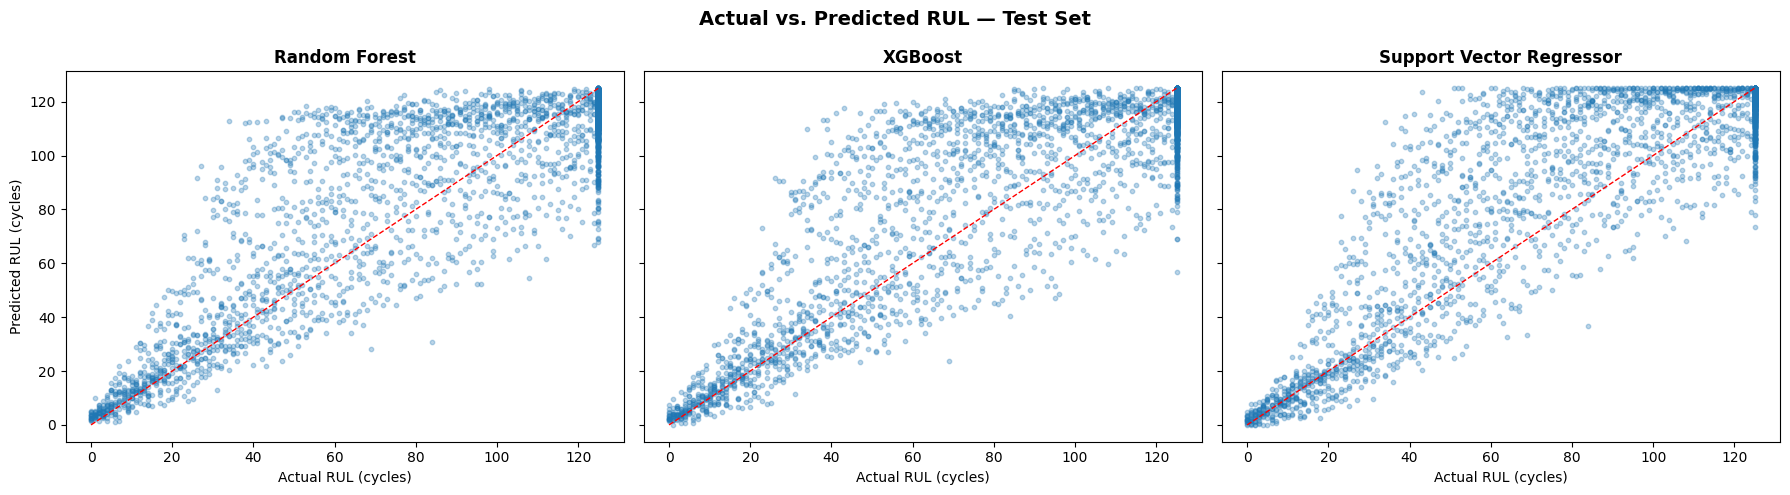

In [9]:
# --- 7b. Actual vs. Predicted RUL scatter, per model ---
fig, axes = plt.subplots(1, len(best_models), figsize=(6 * len(best_models), 5), sharey=True)
if len(best_models) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.3, s=10)
    ax.plot([0, 125], [0, 125], 'r--', linewidth=1)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Actual RUL (cycles)")

axes[0].set_ylabel("Predicted RUL (cycles)")
plt.suptitle("Actual vs. Predicted RUL — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

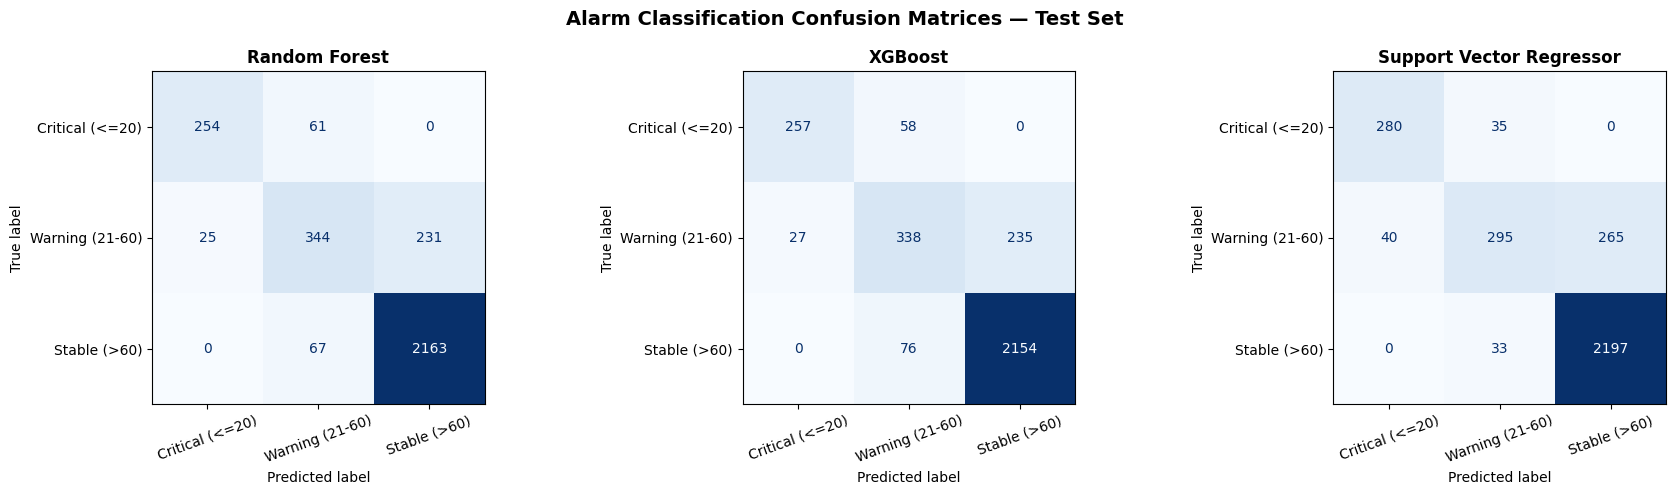

In [10]:
# --- 7c. Alarm-zone confusion matrices, per model ---
fig, axes = plt.subplots(1, len(best_models), figsize=(6 * len(best_models), 5))
if len(best_models) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test_alerts, map_to_alerts(preds))
    disp = ConfusionMatrixDisplay(cm, display_labels=ALERT_LABELS)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
    ax.set_title(name, fontweight="bold")

plt.suptitle("Alarm Classification Confusion Matrices — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

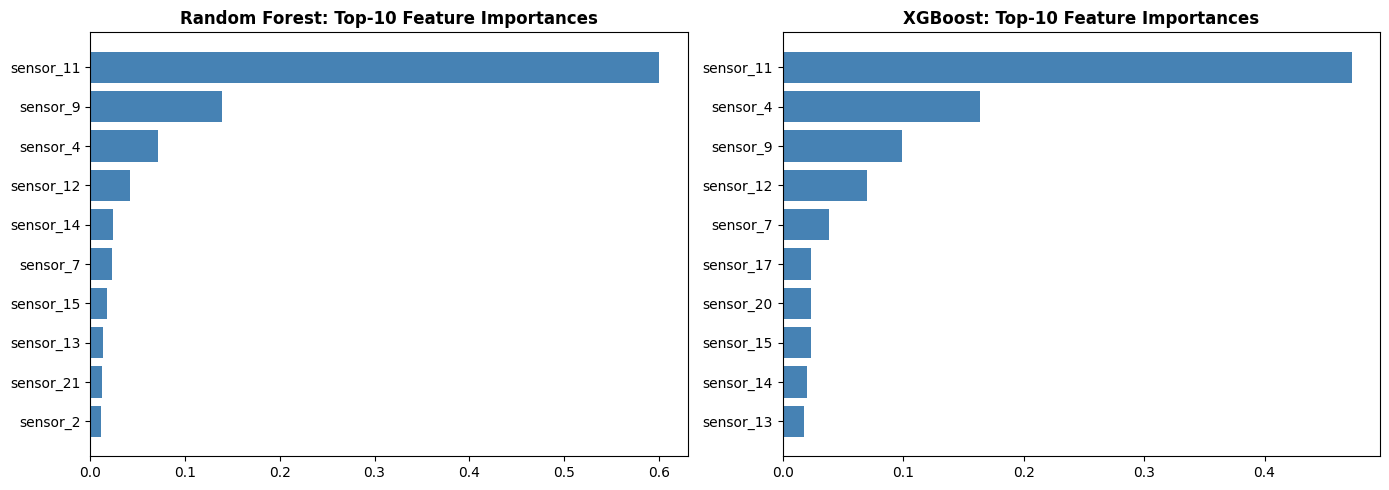

In [11]:
# --- 7d. Feature importance (tree-based models only; SVR has no native importances) ---
importance_models = {n: m for n, m in best_models.items() if hasattr(m, "feature_importances_")}

if importance_models:
    fig, axes = plt.subplots(1, len(importance_models), figsize=(7 * len(importance_models), 5))
    if len(importance_models) == 1:
        axes = [axes]
    for ax, (name, model) in zip(axes, importance_models.items()):
        importances = model.feature_importances_
        order = np.argsort(importances)[::-1][:10]
        ax.barh([active_features[i] for i in order][::-1], importances[order][::-1], color="steelblue")
        ax.set_title(f"{name}: Top-10 Feature Importances", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based models with native feature_importances_ in this run.")